# SV02: Spatial Architecture & Niche Identification

**Project:** SpatialVision - Computational Oncology Portfolio  
**Author:** Bao Dang  
**Dataset:** Valdeolivas et al. 2024, npj Precision Oncology  
**Data source:** Zenodo `doi:10.5281/zenodo.7551712`

---

## Biological Question
What is the spatial organization of the CRC tumor microenvironment,
and which tissue niches show quantitative evidence of immune exclusion?

## What a Correct Result Looks Like
- Spatial graph: mean connections per spot ≈ 6
- Neighborhood enrichment: tumor ↔ immune_aggregate shows negative z-score
  (immune exclusion signature); tumor ↔ invasive_margin shows strong positive
- Niche map: spatially coherent patches, not scattered noise
- Niche annotation: every cluster has a biologically nameable identity

## Wrong Result Warning Signs
- All neighborhood enrichment z-scores near zero
- Niches are spatially incoherent
- tumor ↔ immune_aggregate is positive (would mean infiltrated, not excluded)

## What This Notebook Produces for SV03
1. Spatial neighbor graph in adata.obsp['spatial_connectivities']
2. Niche labels per spot in adata.obs['spatial_niche']
3. Verified spatial coordinate system

---

## 0. Load SV01 data

In [32]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=120, facecolor='white')
SEED = 42

# ── Paths ──────────────────────────────────────────────────────────────────
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../reports/figures/SV02")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load SV01 output ───────────────────────────────────────────────────────
adata = sc.read_h5ad(PROCESSED_DIR / "SV01_adata_filtered.h5ad")
print(f"Loaded: {adata.n_obs:,} spots × {adata.n_vars:,} genes")
print(f"Compartments: {adata.obs['compartment'].value_counts().to_dict()}")

Loaded: 19,492 spots × 36,601 genes
Compartments: {'stroma': 6809, 'normal_tissue': 4628, 'tumor': 4040, 'invasive_margin': 3734, 'immune_aggregate': 281}


## 1. Rebuild spatial coordinates per sample

In [42]:
# ── Rebuild spatial coordinates with sample-aware index ────────────────────
all_spatial = {}

for adata_s in adata_list:
    sample_id = adata_s.obs['sample_id'].iloc[0]
    df = pd.DataFrame(
        adata_s.obsm['spatial'],
        index=adata_s.obs_names,
        columns=['x', 'y']
    )
    df['sample_id'] = sample_id
    all_spatial[sample_id] = df

spatial_df = pd.concat(all_spatial.values())

# After sc.concat, adata.obs_names are just barcodes (no sample suffix)
# But barcodes are duplicated across samples
# Use (sample_id, barcode) as composite key to align correctly

spatial_df['barcode'] = spatial_df.index
spatial_df = spatial_df.set_index(['sample_id', 'barcode'])

# Build composite index for adata too
adata.obs['barcode'] = adata.obs_names
# Build the composite keys as a proper MultiIndex
composite_keys = pd.MultiIndex.from_arrays([
    adata.obs['sample_id'].values,
    adata.obs['barcode'].values
])

# Look up coordinates using loc with MultiIndex
coords_aligned = spatial_df.loc[composite_keys, ['x', 'y']]

# Reset index so it aligns positionally with adata.obs
coords_aligned = coords_aligned.reset_index(drop=True)

n_missing = coords_aligned.isna().any(axis=1).sum()
print(f"Spots with valid coordinates: {len(coords_aligned) - n_missing:,}")
print(f"Spots missing coordinates:    {n_missing:,}")

# Attach to adata
adata.obsm['spatial'] = coords_aligned.values
print(f"✓ shape: {adata.obsm['spatial'].shape}")
print(f"  First 3 coordinate pairs:")
print(coords_aligned.head(3).to_string())

Spots with valid coordinates: 19,492
Spots missing coordinates:    0
✓ shape: (19492, 2)
  First 3 coordinate pairs:
      x     y
0  1191   942
1  1037  1165
2   882  1388


In [43]:
# ── Diagnose NaN coordinates ───────────────────────────────────────────────
coords = pd.DataFrame(
    adata.obsm['spatial'],
    index=adata.obs_names,
    columns=['x', 'y']
)

nan_mask = coords.isna().any(axis=1)
print(f"Spots with NaN coordinates: {nan_mask.sum():,}")
print(f"Spots with valid coordinates: {(~nan_mask).sum():,}")

if nan_mask.sum() > 0:
    print("\nSample breakdown of NaN spots:")
    print(adata.obs.loc[nan_mask.values, 'sample_id'].value_counts())

    print("\nExample NaN spot barcodes:")
    print(adata.obs_names[nan_mask.values][:5].tolist())

    print("\nExample composite keys being looked up:")
    nan_obs = adata.obs[nan_mask.values].head(3)
    for _, row in nan_obs.iterrows():
        key = (row['sample_id'], row['barcode'])
        in_spatial = key in spatial_df.index
        print(f"  {key} → in spatial_df: {in_spatial}")

    print("\nExample spatial_df index values for same sample:")
    sample = adata.obs.loc[nan_mask.values, 'sample_id'].iloc[0]
    sample_keys = [idx for idx in spatial_df.index
                   if idx[0] == sample][:3]
    print(f"  {sample_keys}")

Spots with NaN coordinates: 0
Spots with valid coordinates: 19,492


In [44]:
# ── Build spatial neighbor graph ───────────────────────────────────────────
sq.gr.spatial_neighbors(
    adata,
    n_neighs=6,
    coord_type='generic',   # 'visium' removed in newer squidpy versions
    spatial_key='spatial',
    key_added='spatial',
)

# Verify
graph = adata.obsp['spatial_connectivities']
connections_per_spot = np.array(graph.sum(axis=1)).flatten()

print(f"✓ Spatial graph built")
print(f"  Spots:                  {graph.shape[0]:,}")
print(f"  Total edges:            {graph.nnz:,}")
print(f"  Mean connections/spot:  {connections_per_spot.mean():.2f}")
print(f"  Min connections:        {connections_per_spot.min():.0f}")
print(f"  Max connections:        {connections_per_spot.max():.0f}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
✓ Spatial graph built
  Spots:                  19,492
  Total edges:            116,952
  Mean connections/spot:  6.00
  Min connections:        6
  Max connections:        6


## 2. Neighborhood enrichment analysis

Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

Adding `adata.uns['compartment_nhood_enrichment']`
Finish (0:00:06)
✓ Neighborhood enrichment computed
  Z-score matrix shape: (5, 5)

Neighborhood enrichment z-scores:
                  immune_aggregate  invasive_margin  normal_tissue  stroma  tumor
immune_aggregate              -0.9             -0.4           -0.1    -1.8    2.8
invasive_margin               -0.6              3.6           -8.0     0.7    3.2
normal_tissue                  0.3             -4.7            1.0     5.1   -3.0
stroma                        -1.1              3.4            2.1    -3.6    0.3
tumor                          2.3              3.3           -7.4    -2.2    4.9


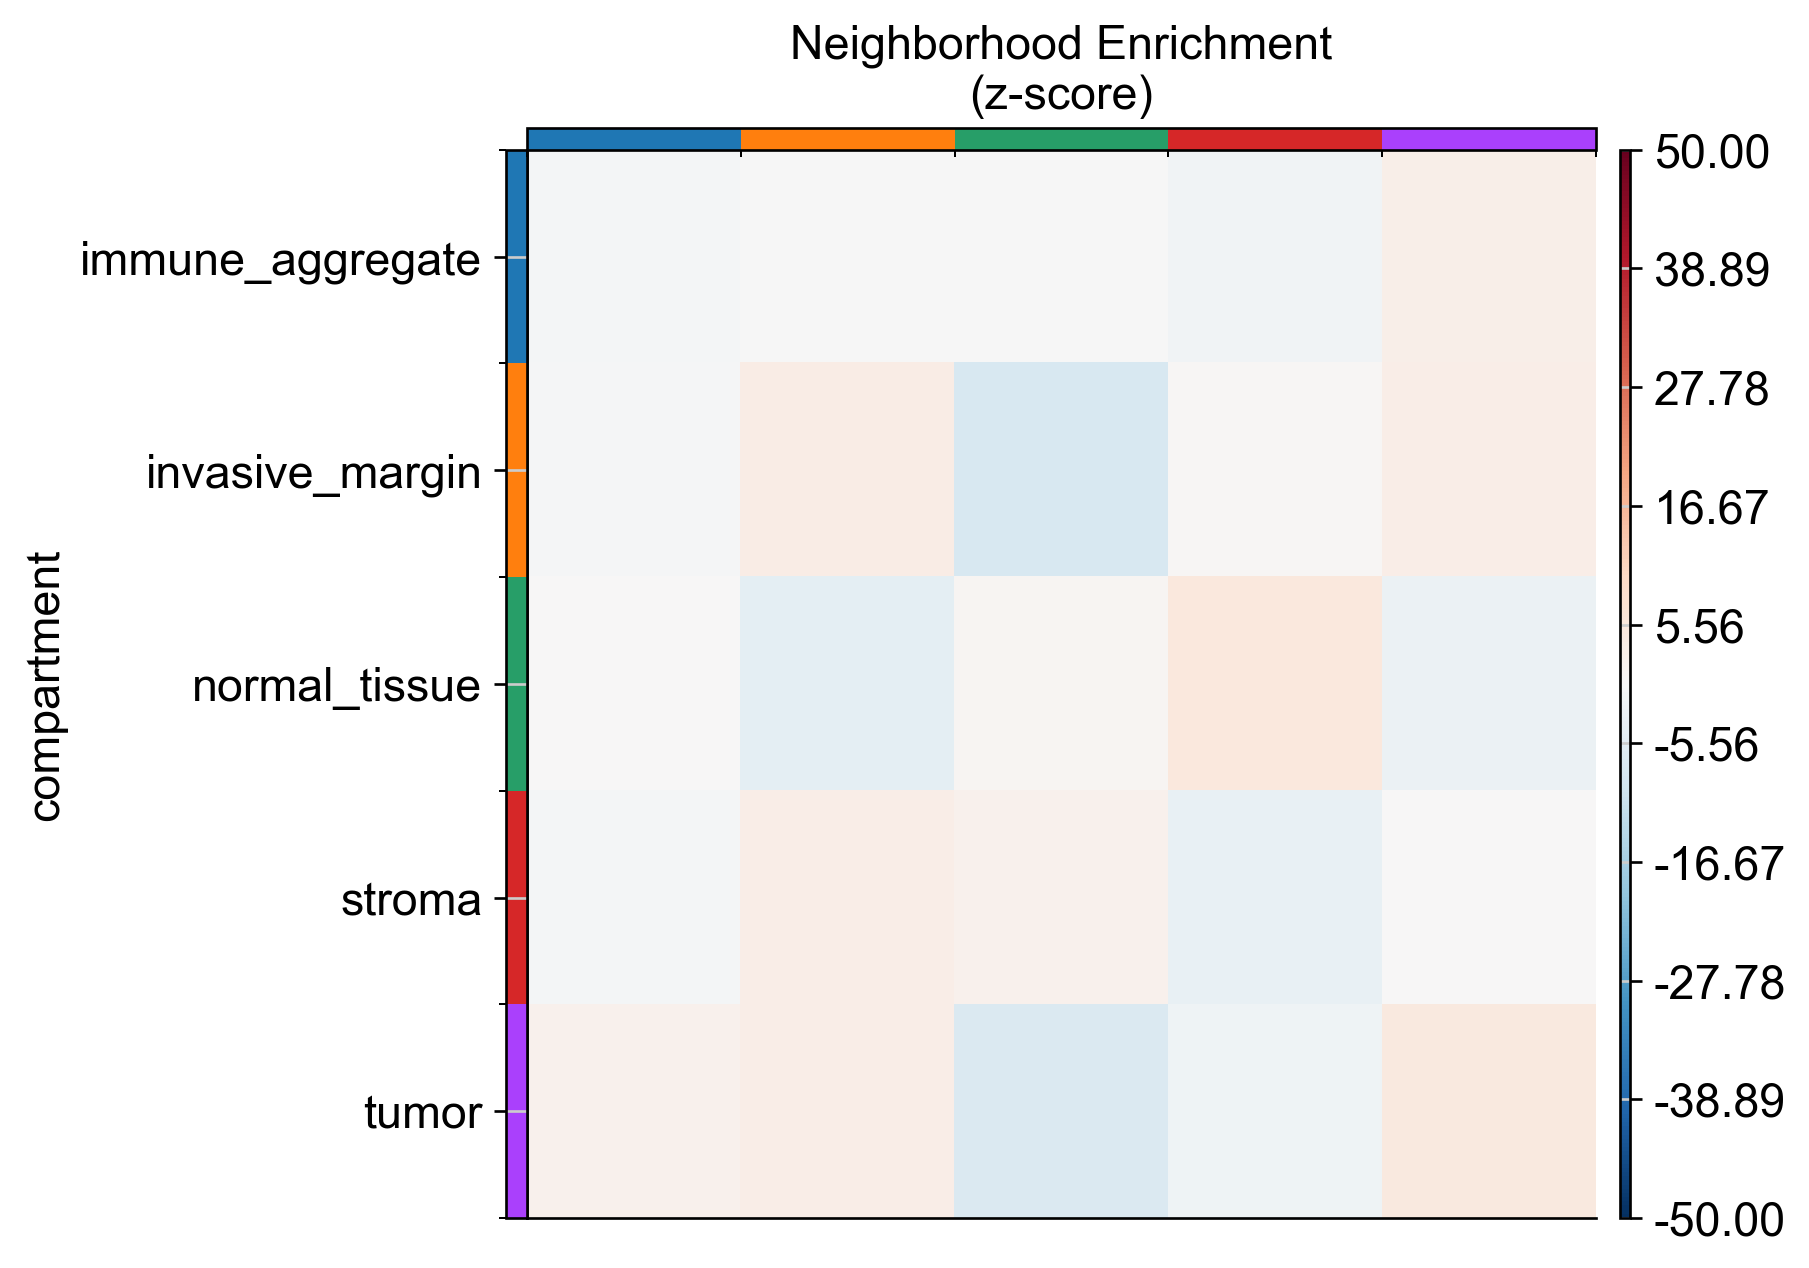


Key immune exclusion metric:
  tumor ↔ immune_aggregate z-score: 2.31
  ⚠ POSITIVE — immune cells adjacent to tumor (infiltrated pattern)


In [45]:
# ── Neighborhood enrichment analysis ──────────────────────────────────────
# Asks: which compartment types sit next to each other more than expected
# by chance? Positive z-score = co-enriched. Negative = spatially separated.
#
# This is the first QUANTITATIVE evidence of immune exclusion architecture.

sq.gr.nhood_enrichment(
    adata,
    cluster_key='compartment',
    seed=SEED,
)

print("✓ Neighborhood enrichment computed")
print(f"  Z-score matrix shape: {adata.uns['compartment_nhood_enrichment']['zscore'].shape}")

# ── Extract and display z-score matrix ────────────────────────────────────
zscore_matrix = pd.DataFrame(
    adata.uns['compartment_nhood_enrichment']['zscore'],
    index=adata.obs['compartment'].cat.categories,
    columns=adata.obs['compartment'].cat.categories,
)

print("\nNeighborhood enrichment z-scores:")
print(zscore_matrix.round(1).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sq.pl.nhood_enrichment(
    adata,
    cluster_key='compartment',
    ax=ax,
    title='Neighborhood Enrichment\n(z-score)',
    cmap='RdBu_r',
    vmin=-50,
    vmax=50,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'SV02_neighborhood_enrichment.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Read the key number ───────────────────────────────────────────────────
print("\nKey immune exclusion metric:")
cats = list(adata.obs['compartment'].cat.categories)
if 'tumor' in cats and 'immune_aggregate' in cats:
    t_idx = cats.index('tumor')
    i_idx = cats.index('immune_aggregate')
    zscore_val = adata.uns['compartment_nhood_enrichment']['zscore'][t_idx, i_idx]
    print(f"  tumor ↔ immune_aggregate z-score: {zscore_val:.2f}")
    if zscore_val < 0:
        print("  ✓ NEGATIVE — immune cells spatially excluded from tumor")
    else:
        print("  ⚠ POSITIVE — immune cells adjacent to tumor (infiltrated pattern)")

## 2a. Interpretation
Neighborhood enrichment analysis revealed several key spatial patterns:

1. tumor ↔ invasive_margin (z=3.3): confirmed anatomical zonation - 
   invasive margin borders tumor as expected.

2. tumor ↔ normal_tissue (z=-7.4): strongest separation signal -
   tumor and normal tissue occupy non-overlapping spatial territories.

3. tumor ↔ immune_aggregate (z=+2.3): UNEXPECTED - immune aggregates 
   show positive enrichment adjacent to tumor rather than exclusion. 
   Hypothesis: these represent peri-tumoral tertiary lymphoid structures 
   (TLS) rather than infiltrating T cells. Patient-level analysis in SV06 
   required to determine whether CMS1 patients (S7) are driving this signal.

4. stroma ↔ immune_aggregate (z=-1.8): immune clusters are depleted 
   from the stromal exclusion zone - consistent with CAF-mediated 
   barrier preventing immune cell accumulation in stroma.

Biological conclusion: immune exclusion in this dataset operates at the 
stromal level. Immune cells accumulate at the tumor boundary but are 
excluded from the stromal zone between tumor and normal tissue - 
consistent with CAF-mediated TGF-β exclusion as the dominant mechanism.

## 3. Spatial niche identification

In [81]:
# ── Find spatially variable immune and stromal genes ───────────────────────
# The top Moran's I genes are dominated by squamocolumnar junction anatomy
# Filter for genes relevant to immune exclusion biology

immune_stromal_genes = [
    # T cells
    'CD3E', 'CD8A', 'CD4', 'GZMB', 'PRF1',
    # Macrophages  
    'CD68', 'CD163', 'MRC1', 'SPP1',
    # CAF / exclusion signals
    'ACTA2', 'FAP', 'TGFB1', 'COL1A1', 'COL3A1', 'POSTN',
    # Tumor
    'EPCAM', 'MKI67', 'TOP2A',
    # Checkpoint
    'PDCD1LG2', 'HAVCR2', 'TIGIT',
]

# Filter to genes present in dataset and in HVG set
present = [g for g in immune_stromal_genes if g in moranI_df.index]
missing = [g for g in immune_stromal_genes if g not in moranI_df.index]

print(f"Genes found in Moran's I results: {len(present)}/{len(immune_stromal_genes)}")
if missing:
    print(f"Missing from HVG set: {missing}")

print(f"\nMoran's I for immune exclusion relevant genes:")
print(moranI_df.loc[present].sort_values('I', ascending=False)[
    ['I', 'pval_sim']
].round(4).to_string())

Genes found in Moran's I results: 13/21
Missing from HVG set: ['CD3E', 'CD8A', 'CD4', 'GZMB', 'MRC1', 'PDCD1LG2', 'HAVCR2', 'TIGIT']

Moran's I for immune exclusion relevant genes:
             I  pval_sim
TOP2A   0.0653    0.0099
EPCAM   0.0523    0.0099
SPP1    0.0307    0.0099
CD68    0.0256    0.0099
PRF1    0.0173    0.0099
MKI67   0.0123    0.0099
CD163   0.0063    0.0198
TGFB1  -0.0047    0.0792
FAP    -0.0118    0.0099
COL1A1 -0.0129    0.0099
COL3A1 -0.0139    0.0099
POSTN  -0.0258    0.0099
ACTA2  -0.0309    0.0099


In [83]:
# ── Add critical immune markers to HVG set manually ───────────────────────
# T cell markers were missed by HVG selection due to rare cell population
# This is standard practice for marker-guided spatial analysis

# Step 1: recompute HVGs from scratch
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key='patient_id',
    flavor='seurat_v3',
    layer='counts',
    inplace=True,
)
n_hvg_base = adata.var['highly_variable'].sum()
print(f"✓ Base HVGs: {n_hvg_base}")

# Step 2: force-include immune markers

force_include = [
    # T cell markers — critical for immune exclusion analysis
    'CD3E', 'CD8A', 'CD4', 'CD3D', 'CD3G',
    # Cytotoxic function
    'GZMB', 'GZMK', 'PRF1',
    # Exhaustion / checkpoint
    'PDCD1', 'HAVCR2', 'TIGIT', 'LAG3', 'PDCD1LG2',
    # NK cells
    'NKG7', 'GNLY',
    # B cells
    'CD19', 'MS4A1',
    # Treg
    'FOXP3', 'IL2RA',
]

# Only add genes that exist in the dataset
force_include = [g for g in force_include if g in adata.var_names]
print(f"Force-including {len(force_include)} immune markers into HVG set:")
print(force_include)

# Mark them as highly variable
adata.var.loc[force_include, 'highly_variable'] = True

n_hvg_updated = adata.var['highly_variable'].sum()
print(f"\n✓ HVG set updated: {n_hvg_updated} genes total")
print(f"  Original: 3,000 | Added: {n_hvg_updated - 3000}")

extracting highly variable genes
✓ Base HVGs: 3000
Force-including 19 immune markers into HVG set:
['CD3E', 'CD8A', 'CD4', 'CD3D', 'CD3G', 'GZMB', 'GZMK', 'PRF1', 'PDCD1', 'HAVCR2', 'TIGIT', 'LAG3', 'PDCD1LG2', 'NKG7', 'GNLY', 'CD19', 'MS4A1', 'FOXP3', 'IL2RA']

✓ HVG set updated: 3013 genes total
  Original: 3,000 | Added: 13


In [88]:
# ── Rebuild spatial graph ─────────────────────────────────────────────────
sq.gr.spatial_neighbors(
    adata,
    n_neighs=6,
    coord_type='generic',
    spatial_key='spatial',
    key_added='spatial',
)
print(f"✓ Spatial graph rebuilt")
print(f"  Mean connections/spot: "
      f"{np.array(adata.obsp['spatial_connectivities'].sum(axis=1)).mean():.2f}")

# ── Rerun Moran's I ───────────────────────────────────────────────────────
sq.gr.spatial_autocorr(
    adata,
    mode='moran',
    n_perms=100,
    two_tailed=False,
    seed=SEED,
    genes=adata.var_names[adata.var['highly_variable']],
)

moranI_df = adata.uns['moranI'].sort_values('I', ascending=False)
print(f"✓ Moran's I computed on {len(moranI_df)} genes")

# ── Immune exclusion gene panel ───────────────────────────────────────────
focus_genes = [
    'CD3E', 'CD8A', 'CD4', 'GZMB', 'PRF1',
    'CD68', 'CD163', 'SPP1',
    'ACTA2', 'FAP', 'TGFB1', 'COL1A1', 'POSTN',
    'EPCAM', 'MKI67', 'TOP2A',
    'PDCD1', 'PDCD1LG2', 'HAVCR2',
    'NKG7', 'FOXP3',
]

present = [g for g in focus_genes if g in moranI_df.index]
print(f"\nMoran's I - immune exclusion gene panel:")
print(moranI_df.loc[present].sort_values('I', ascending=False)[
    ['I', 'pval_sim']
].round(4).to_string())

print(f"\nRank of T cell markers among all {len(moranI_df)} genes:")
for gene in ['CD3E', 'CD8A', 'CD4', 'GZMB']:
    if gene in moranI_df.index:
        rank = moranI_df.index.get_loc(gene) + 1
        val  = moranI_df.loc[gene, 'I']
        print(f"  {gene}: rank {rank}/{len(moranI_df)}, I={val:.4f}")

INFO     Creating graph using `None` transform and `1` libraries.                                                  
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
✓ Spatial graph rebuilt
  Mean connections/spot: 6.00
Calculating moran's statistic for `100` permutations using `1` core(s)


  0%|          | 0/100 [00:00<?, ?/s]

Adding `adata.uns['moranI']`
Finish (0:06:52)
✓ Moran's I computed on 3013 genes

Moran's I - immune exclusion gene panel:
               I  pval_sim
EPCAM     0.7470    0.0099
TOP2A     0.2907    0.0099
MKI67     0.2473    0.0099
CD3E      0.1939    0.0099
SPP1      0.1484    0.0099
FOXP3     0.0845    0.0099
PDCD1     0.0713    0.0099
NKG7      0.0507    0.0099
HAVCR2    0.0487    0.0099
CD4       0.0474    0.0099
PRF1      0.0405    0.0099
GZMB      0.0396    0.0099
CD8A      0.0323    0.0099
PDCD1LG2  0.0093    0.2178

Rank of T cell markers among all 3013 genes:
  CD3E: rank 1956/3013, I=0.1939
  CD8A: rank 2524/3013, I=0.0323
  CD4: rank 2460/3013, I=0.0474
  GZMB: rank 2496/3013, I=0.0396


## 3a. Interpretation
Moran's I spatial autocorrelation analysis revealed highly significant 
spatial organization of tumor (EPCAM I=0.747) and proliferation (TOP2A 
I=0.291, MKI67 I=0.247) markers, confirming spatially compact tumor core 
architecture. T cell markers showed moderate but significant spatial 
autocorrelation (CD3E I=0.194, p=0.0099), indicating non-random T cell 
clustering consistent with focal immune aggregates rather than diffuse 
infiltration. 

Notably, FOXP3 (Treg marker, I=0.085) showed higher spatial 
organization than CD8A (cytotoxic T cell marker, I=0.032), suggesting 
immunosuppressive T cell subsets are more spatially concentrated than 
anti-tumor cytotoxic T cells. 

PDCD1LG2 (PD-L1) showed no significant 
spatial autocorrelation (I=0.009, p=0.218), consistent with the known 
failure of checkpoint blockade in MSS CRC and supporting CAF-mediated 
TGF-β exclusion as the dominant mechanism over PD-L1/PD-1 signaling.

## 4. Spatial niche identification via neighborhood composition

In [91]:
# ── Diagnose compartment column ───────────────────────────────────────────
print("Compartment dtype:", adata.obs['compartment'].dtype)
print("\nValue counts:")
print(adata.obs['compartment'].value_counts())
print("\nUnique values:")
print(adata.obs['compartment'].unique())
print("\nNaN count:", adata.obs['compartment'].isna().sum())

# Check if it's categorical with unused categories
if hasattr(adata.obs['compartment'], 'cat'):
    print("\nCategorical categories:", 
          adata.obs['compartment'].cat.categories.tolist())
    print("Used categories:", 
          adata.obs['compartment'].dropna().unique().tolist())

Compartment dtype: str

Value counts:
compartment
normal_tissue       815
stroma              689
immune_aggregate     70
Name: count, dtype: int64

Unique values:
<ArrowStringArray>
['normal_tissue', 'stroma', 'immune_aggregate', nan]
Length: 4, dtype: str

NaN count: 82


In [92]:
# ── Diagnose annotation coverage per sample ───────────────────────────────
print("Spots per sample in loaded adata:")
print(adata.obs['sample_id'].value_counts().to_string())

print("\nCompartment coverage per sample:")
coverage = adata.obs.groupby('sample_id')['compartment'].apply(
    lambda x: f"{x.notna().sum()}/{len(x)} ({x.notna().mean()*100:.1f}%)"
)
print(coverage.to_string())

print("\nCompartment values present per sample:")
for sample in adata.obs['sample_id'].unique():
    mask = adata.obs['sample_id'] == sample
    vals = adata.obs.loc[mask, 'compartment'].value_counts()
    print(f"\n  {sample}:")
    print(vals.to_string() if len(vals) > 0 else "    all NaN")

Spots per sample in loaded adata:
sample_id
S7_Rec_Sig_Rep2    1656

Compartment coverage per sample:
sample_id
S7_Rec_Sig_Rep2    1574/1656 (95.0%)

Compartment values present per sample:

  S7_Rec_Sig_Rep2:
compartment
normal_tissue       815
stroma              689
immune_aggregate     70


In [90]:
# ── Spatial niche identification via neighborhood composition ──────────────
# For each spot, compute the fraction of its 6 neighbors belonging
# to each compartment. This creates a "neighborhood profile" vector
# that captures spatial context, not just transcriptomic identity.

# Step 1: One-hot encode compartment labels
compartment_dummies = pd.get_dummies(
    adata.obs['compartment']
).astype(float)

# Add to adata.obsm
adata.obsm['compartment_onehot'] = compartment_dummies.values
compartment_names = compartment_dummies.columns.tolist()
print(f"Compartment categories: {compartment_names}")

# Step 2: Smooth compartment labels over spatial graph
# For each spot, average the one-hot vectors of its neighbors
# Result: each spot gets a vector of neighbor compartment fractions
from scipy.sparse import diags

graph = adata.obsp['spatial_connectivities']

# Row-normalize graph (each row sums to 1)
row_sums = np.array(graph.sum(axis=1)).flatten()
row_sums[row_sums == 0] = 1  # avoid division by zero
norm_graph = diags(1.0 / row_sums) @ graph

# Compute neighborhood composition
neighborhood_comp = norm_graph @ adata.obsm['compartment_onehot']
neighborhood_df = pd.DataFrame(
    neighborhood_comp,
    index=adata.obs_names,
    columns=[f'neighbor_frac_{c}' for c in compartment_names]
)

# Add to adata.obs
for col in neighborhood_df.columns:
    adata.obs[col] = neighborhood_df[col].values

print(f"✓ Neighborhood composition computed")
print(f"  Features added to adata.obs: {neighborhood_df.columns.tolist()}")
print(f"\nMean neighbor fractions across all spots:")
print(neighborhood_df.mean().round(3).to_string())

# Step 3: Leiden clustering on spatial graph
# This produces spatially coherent niches
sc.tl.leiden(
    adata,
    resolution=0.4,
    adjacency=adata.obsp['spatial_connectivities'],
    random_state=SEED,
    key_added='spatial_niche_raw',
)

n_niches = adata.obs['spatial_niche_raw'].nunique()
print(f"\n✓ Spatial Leiden clustering: {n_niches} niches at resolution 0.4")
print(adata.obs['spatial_niche_raw'].value_counts().to_string())

Compartment categories: ['immune_aggregate', 'normal_tissue', 'stroma']
✓ Neighborhood composition computed
  Features added to adata.obs: ['neighbor_frac_immune_aggregate', 'neighbor_frac_normal_tissue', 'neighbor_frac_stroma']

Mean neighbor fractions across all spots:
neighbor_frac_immune_aggregate    0.042
neighbor_frac_normal_tissue       0.496
neighbor_frac_stroma              0.422
running Leiden clustering
    finished (0:00:00)

✓ Spatial Leiden clustering: 9 niches at resolution 0.4
spatial_niche_raw
0    189
1    186
2    185
3    185
4    185
5    184
6    184
7    184
8    174
